# 07 — Landscape / habitat structure metrics

Per-zone canopy metrics (from the CHM) and class-level **fragmentation** metrics
(FRAGSTATS-style, from the step-05 habitat raster), computed with scipy.ndimage —
no FRAGSTATS/pylandstats dependency.

- **Canopy:** cover (% ≥ 2 m, ≥ 3 m), mean canopy height, p95 / max height.
- **Fragmentation** (forest canopy & low vegetation): number of patches, patch
  density, mean patch size, largest patch index, edge density.

**Inputs:** `outputs/04_chm/{talar,pastizal}_chm_*0p5m.tif`,
`outputs/05_segmentation/{zone}_habitat_0p5m.tif`, `data/Area.shp`.
**Outputs:** `outputs/07_metrics/` — canopy + fragmentation tables, figures.

**Wetland extent** is requested in the project goals but **not available** — wetland
was not separable in RGB (step 05), so we don't report a wetland metric.

In [1]:
from pathlib import Path
from dataclasses import asdict
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent
from scipy import ndimage

from drone_reserve.landmetrics import clip_to_geom, canopy_metrics, class_metrics
from drone_reserve.segment import CLASS_NAMES

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "pyproject.toml").is_file():
        REPO = parent; break
else:
    raise RuntimeError("repo root not found")

DATA = REPO / "data"
CHMD = REPO / "outputs" / "04_chm"
SEG  = REPO / "outputs" / "05_segmentation"
OUT  = REPO / "outputs" / "07_metrics"
FIGS = OUT / "figs"
OUT.mkdir(parents=True, exist_ok=True); FIGS.mkdir(parents=True, exist_ok=True)

area = gpd.read_file(DATA / "Area.shp").to_crs(32721)
ZONES = {
    "talar":    {"chm": CHMD / "talar_chm_corrected_0p5m.tif",
                  "hab": SEG / "talar_habitat_0p5m.tif",  "area_id": 1},
    "pastizal": {"chm": CHMD / "pastizal_chm_0p5m.tif",
                  "hab": SEG / "pastizal_habitat_0p5m.tif", "area_id": 2},
}
for z in ZONES:
    ZONES[z]["geom"] = [area.loc[area["id"] == ZONES[z]["area_id"], "geometry"].iloc[0].__geo_interface__]
print("OK")

OK


## Canopy metrics (per zone)

In [2]:
pd.set_option("display.float_format", lambda v: f"{v:.2f}")
canopy_rows = []
for zone, p in ZONES.items():
    chm, valid, px, zarea = clip_to_geom(p["chm"], p["geom"])
    canopy_rows.append(asdict(canopy_metrics(chm, valid, zone, zarea)))
canopy_tbl = pd.DataFrame(canopy_rows).set_index("zone")
canopy_tbl

,zone_area_ha,cover_2m_pct,cover_3m_pct,mean_canopy_height_m,p95_height_m,max_height_m,mean_height_all_m
zone,,,,,,,
talar,11.87,28.80,20.20,4.31,5.83,17.40,1.59
pastizal,13.39,20.90,15.00,4.64,5.95,21.74,1.19


## Fragmentation metrics (forest canopy & low vegetation, per zone)

In [3]:
# Per-pixel segmentation is salt-and-pepper, so sieve to a minimum mapping unit first
# (25 m^2 = 100 px at 0.5 m) — otherwise patch counts are noise (651 vs 80 forest patches).
from drone_reserve.landmetrics import sieve_habitat
MMU_PX = 100  # 25 m^2 minimum mapping unit

frag_rows = []
sieved_by_zone = {}
for zone, p in ZONES.items():
    hab, valid, px, zarea = clip_to_geom(p["hab"], p["geom"])
    hab_s = sieve_habitat(hab, valid, min_pixels=MMU_PX)
    sieved_by_zone[zone] = (hab_s, valid, px, zarea)
    for cid in [0, 1]:  # forest canopy, low vegetation
        m = class_metrics(hab_s, valid, class_id=cid, class_name=CLASS_NAMES[cid],
                          zone=zone, pixel_size=px, zone_area_ha=zarea)
        frag_rows.append(asdict(m))
frag_tbl = pd.DataFrame(frag_rows).set_index(["zone", "class_name"])
print(f"Fragmentation after {MMU_PX*0.25:.0f} m^2 MMU sieve:")
frag_tbl

Fragmentation after 25 m^2 MMU sieve:


area_ha  pct_of_zone  n_patches  \
zone     class_name                                        
talar    forest canopy      2.31        19.50         80   
         low vegetation     3.61        30.40         50   
pastizal forest canopy      1.80        13.50        102   
         low vegetation     6.13        45.80         52   

                         patch_density_per_100ha  mean_patch_size_ha  \
zone     class_name                                                    
talar    forest canopy                    674.60                0.03   
         low vegetation                   421.60                0.07   
pastizal forest canopy                    762.50                0.02   
         low vegetation                   388.70                0.12   

                         largest_patch_index_pct  edge_density_m_per_ha  
zone     class_name                                                      
talar    forest canopy                      5.20                1171.00  
         low vegetation                    13.40                1673.90  
pastizal forest canopy                      1.80                 792.50  
         low vegetation                    15.00                2185.40

## Figures

C:\Users\paco_\AppData\Local\Temp\ipykernel_34056\710195001.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIGS / "forest_patches.png", dpi=140); fig.show()


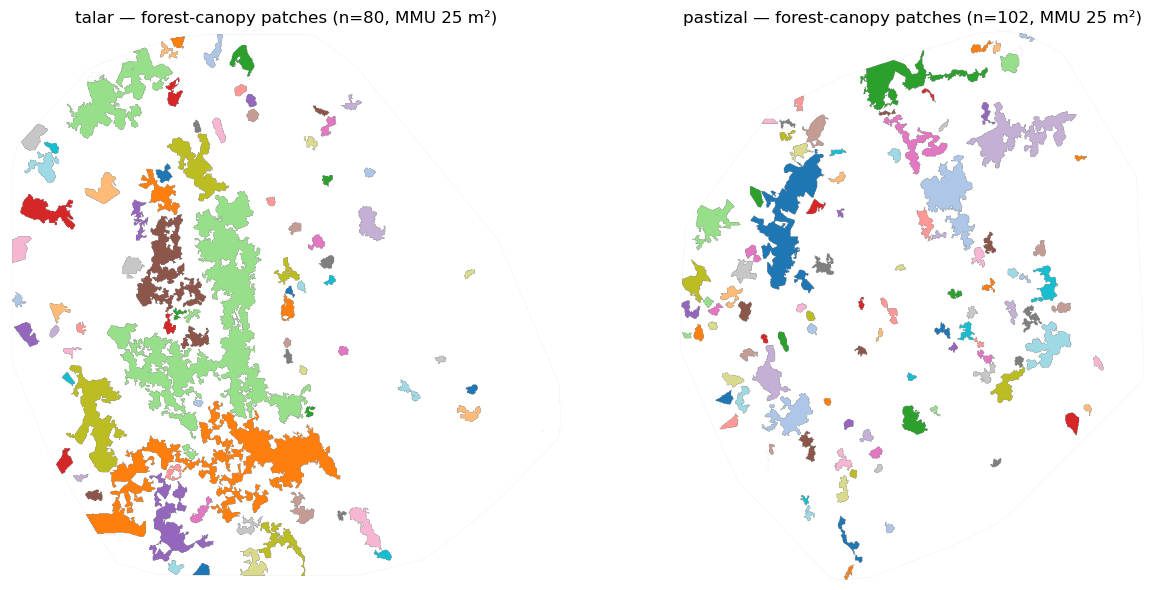

In [4]:
# Forest-canopy patches per zone (after MMU sieve), each patch a different colour.
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, zone in zip(axes, ZONES):
    hab_s, valid, px, zarea = sieved_by_zone[zone]
    forest = (hab_s == 0) & valid
    labels, n = ndimage.label(forest, structure=np.ones((3, 3), int))
    disp = np.where(labels > 0, labels % 20 + 1, np.nan)
    ax.imshow(np.where(valid, 0, np.nan), cmap="Greys", vmin=0, vmax=1, alpha=0.15)
    ax.imshow(disp, cmap="tab20")
    ax.set_title(f"{zone} — forest-canopy patches (n={n}, MMU 25 m²)"); ax.set_axis_off()
fig.tight_layout(); fig.savefig(FIGS / "forest_patches.png", dpi=140); fig.show()

C:\Users\paco_\AppData\Local\Temp\ipykernel_34056\3200076399.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIGS / "zone_metrics_bars.png", dpi=140); fig.show()


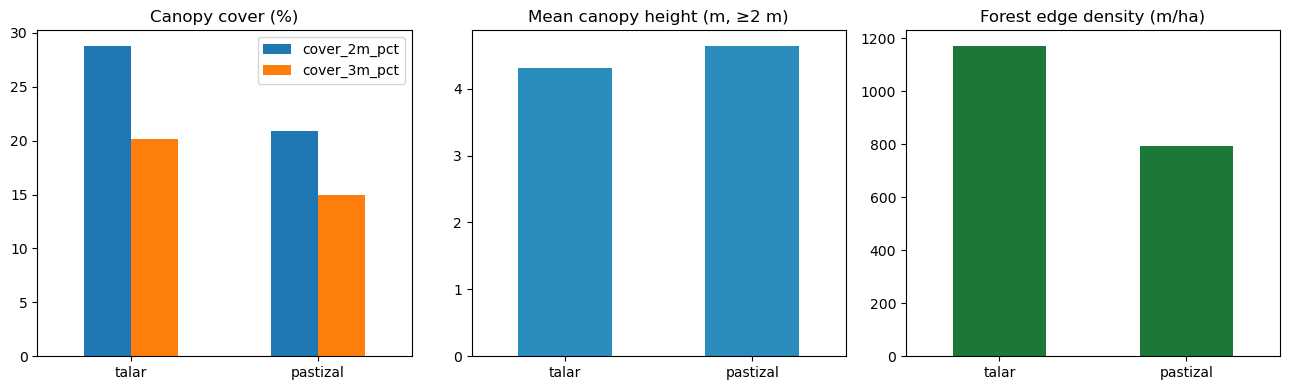

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
canopy_tbl[["cover_2m_pct", "cover_3m_pct"]].plot.bar(ax=axes[0])
axes[0].set_title("Canopy cover (%)"); axes[0].set_xlabel("")
canopy_tbl["mean_canopy_height_m"].plot.bar(ax=axes[1], color="#2b8cbe")
axes[1].set_title("Mean canopy height (m, ≥2 m)"); axes[1].set_xlabel("")
forest_ed = frag_tbl.xs("forest canopy", level="class_name")["edge_density_m_per_ha"]
forest_ed.plot.bar(ax=axes[2], color="#1b7837")
axes[2].set_title("Forest edge density (m/ha)"); axes[2].set_xlabel("")
for ax in axes: ax.tick_params(axis="x", rotation=0)
fig.tight_layout(); fig.savefig(FIGS / "zone_metrics_bars.png", dpi=140); fig.show()

In [6]:
canopy_tbl.to_csv(OUT / "canopy_metrics.csv")
frag_tbl.to_csv(OUT / "fragmentation_metrics.csv")
print("Wrote:")
for p in [OUT / "canopy_metrics.csv", OUT / "fragmentation_metrics.csv"]:
    print(f"  {p}")

Wrote:
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\07_metrics\canopy_metrics.csv
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\07_metrics\fragmentation_metrics.csv


## Findings & caveats

- **Talar is more forested than pastizal:** higher canopy cover (≥2 m: 28.8% vs 20.9%;
  ≥3 m: 20.2% vs 15.0%) and higher mean height across the whole zone (1.59 vs 1.19 m).
  Mean *canopy* height is similar (~4.3–4.6 m). Pastizal has more low vegetation (grassland).
- **Fragmentation requires a minimum mapping unit.** Raw per-pixel patch counts are
  salt-and-pepper noise (651 forest patches); after a **25 m² MMU sieve** the talar forest
  resolves to ~80 patches. Patch counts/density/MPS are reported on the sieved raster; the
  MMU choice is a parameter — report it with the metric.
- **Forest canopy = habitat class 0 (CHM ≥ 3 m)** from step 05; metrics inherit that
  preliminary (unsupervised) segmentation. Largest-patch index and edge density describe how
  connected vs scattered the canopy is.
- **Wetland extent not reported** — wetland is not separable in RGB (no NIR); a data
  limitation, not an omission. **Bare/dry ground** conflates soil + dry vegetation, so it is
  excluded from the habitat metrics.
- All metrics at 0.5 m, clipped to the `Area.shp` footprints (talar ~11.9 ha, pastizal ~13.4 ha).